# Whisking state across learning timepoints

Companion to `wheel_velocity_timepoints`, but for the **binary whisking state** (0/1)
instead of continuous wheel velocity.

Key differences from the wheel script:
* Whisking is a **discrete 2-state** signal, so sequences are time-warped with the
  **mode** (`estimator='mode'`) rather than the mean.
* The raw HMM state label is arbitrary per session, so for **each session** we find
  which state corresponds to high whisking (higher mean `whisker_me`) and remap it so
  **0 = no whisking, 1 = high whisking** before anything else.
* After mode-warping, averaging the 0/1 sequence across trials gives the **fraction of
  time spent whisking** at each normalized timestep, which is what we correlate with LDA 1.

Assumes the per-session whisking-state files already exist (no generation step here —
just a guard). Fill in the blank paths below.

## Parameters

In [138]:
"""
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from one.api import ONE
import sys

sys.path.append(os.path.abspath(
    os.path.join(os.getcwd(), "..", "segmentation", "1_camera_setup")))

from segmentation_functions import (
    align_bin_design_matrix, states_per_trial_phase, broader_label,
    define_trial_types, rescale_sequence,
)

one = ONE(mode='remote')

In [139]:
prefix = "/home/ines/repositories/" 

states_path = prefix + 'representation_learning_variability/paper-individuality/data/training/states_files/'
learning_data_path = prefix + 'representation_learning_variability/paper-individuality/data/training/training_data/'
optimal_k = 4

# LDA table (mouse_name, lda_1 per session)
clustering_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
lda_file =  "mouse_LDA_5_bins_cut19-06-2026"

# LDA dimensions to analyze (1-based; column d-1 in the LDA file, which has dims 1..23).
lda_dim      = 1                       # primary dimension used in the main plots
compare_dims = [1, 2, 3, 5, 10, 20]    # dimensions overlaid in the "flattening" comparison
compare_dims = [1]    # dimensions overlaid in the "flattening" comparison

results_path = prefix + "representation_learning_variability/paper-individuality/learning_individuality/"
os.makedirs(results_path, exist_ok=True)

# --- Column / filename contract for the whisking-state files -----------------
state_file_prefix = '4_states_file_'
# Behavioural variable to analyze. identifiable_states = "{left_paw}{whisk}{lick}{wheel}"
# (digit order = state_columns in 5_syllable_generation).
#   whisk, lick     -> binary (0/1); already oriented so 1 = active
#   left_paw, wheel -> 4 states (0-3); choose which state to isolate via target_state
variable        = "wheel"                       # "left_paw" | "whisk" | "lick" | "wheel"
digit_index_map = {"left_paw": 0, "whisk": 1, "lick": 2, "wheel": 3}
var_digit_index = digit_index_map[variable]
# States to plot as separate lines. None -> auto: binary vars (whisk/lick) use [1]
# (active state; 0 is its complement); multi-state vars (left_paw/wheel) use every state.
states_override = None

# --- Learning timepoints (fractional position within each mouse's sorted sessions) ---
timepoint_fracs = [0.0]
timepoint_names = ["first"]
assert len(timepoint_fracs) == len(timepoint_names)

# --- Trial-type / warping parameters ---
trial_type_agg = ["correct_str", "contrast_str", "block_str", "choice"]
target_length  = 10          # fixed length each whisking sequence is warped to
estimator      = "mode"      # DISCRETE state -> mode per bin (not mean)

# --- Trial alignment window (aligned on go cue) ---
multiplier = 1
event_type_list = ["goCueTrigger_times"]
init = -1.0 * multiplier
end  =  1.5 * multiplier

# Tag added to output filenames so runs are traceable
run_tag = variable

## 1. Load LDA and identify mice of interest

In [140]:
lda = pd.read_pickle(clustering_path + lda_file)
lda = lda.loc[lda['mouse_name'] != 'PL034']

# Keep every dimension we'll need, renamed file-col (0-based) -> lda_<1-based>.
dims = sorted(set([lda_dim] + compare_dims))
lda = lda.rename(columns={d - 1: f"lda_{d}" for d in dims})
lda_cols = [f"lda_{d}" for d in dims]

lda_mice = lda['mouse_name'].unique()
mouse_lda = lda.groupby('mouse_name')[lda_cols].mean().reset_index()   # mean per mouse, per dim
print(f'{len(lda_mice)} LDA mice; dimensions available: {lda_cols}')

55 LDA mice; dimensions available: ['lda_1']


## 2. Select sessions at learning timepoints

In [141]:
# Availability is based on the whisking-state files present on disk.
available_by_mouse = {}
for f in os.listdir(states_path):
    if f.startswith(state_file_prefix):
        rest = f[len(state_file_prefix):]        # "<eid>_<mouse_name>"
        available_by_mouse.setdefault(rest[37:], set()).add(rest[:36])


def select_timepoint_sessions(mice, learning_data_path, available_by_mouse, fracs, names):
    """One session per (mouse, timepoint), chosen by ORDINAL position in the
    mouse's full training history. `has_states` flags whether the chosen eid already
    has a whisking-state file on disk."""
    rows = []
    for mouse_name in sorted(mice):
        f = os.path.join(learning_data_path, "training_data_trials_" + mouse_name)
        if not os.path.exists(f):
            print(f"  [skip] no learning table for {mouse_name}")
            continue

        td = pd.read_parquet(f)
        td["session_date"] = pd.to_datetime(td["session_date"])

        order = (td[["session", "session_date"]]
                 .dropna().drop_duplicates()
                 .sort_values("session_date")
                 .reset_index(drop=True))
        n = len(order)
        if n == 0:
            print(f"  [skip] {mouse_name}: no sessions in learning table")
            continue
        order["session_number"] = np.arange(1, n + 1)

        available = available_by_mouse.get(mouse_name, set())
        for frac, name in zip(fracs, names):
            idx = int(round(frac * (n - 1)))
            r = order.iloc[idx]
            rows.append({
                "mouse_name": mouse_name,
                "session": r["session"],
                "timepoint": name,
                "session_number": int(r["session_number"]),
                "n_sessions": n,
                "session_date": r["session_date"],
                "has_states": r["session"] in available,
            })
    return pd.DataFrame(rows)


selected = select_timepoint_sessions(lda_mice, learning_data_path,
                                     available_by_mouse, timepoint_fracs, timepoint_names)
n_missing = int((~selected["has_states"]).sum())
print(f"Selected {len(selected)} (mouse, timepoint) rows across "
      f"{selected['mouse_name'].nunique()} mice; {n_missing} still lack a whisking-state file.")

# Proceed with whatever is available: report and drop sessions with no state file.
if n_missing:
    print("Skipping (no whisking-state file):")
    for _, r in selected.loc[~selected["has_states"]].iterrows():
        print(f"  {r['mouse_name']}  {r['timepoint']:>6}  {r['session']}")
selected = selected.loc[selected["has_states"]].reset_index(drop=True)
if selected.empty:
    raise RuntimeError(
        f"No selected sessions have a whisking-state file (prefix '{state_file_prefix}') "
        f"in states_path - nothing to analyze.")
print(f"Proceeding with {selected['mouse_name'].nunique()} mice / {len(selected)} sessions "
      f"({selected.groupby('timepoint')['mouse_name'].nunique().to_dict()} per timepoint).")
selected.head()

Selected 55 (mouse, timepoint) rows across 55 mice; 17 still lack a whisking-state file.
Skipping (no whisking-state file):
  CSHL045   first  b117ed10-6871-42b3-9193-ca708dac4353
  CSHL060   first  32088c28-be54-4e32-9f8e-a03c4f85c6d0
  DY_020   first  575b16d1-0480-4d00-a4c7-2cd0871e436a
  NR_0019   first  4636ab1e-0522-472b-8eda-69b4223677c7
  NR_0020   first  378cfd07-0ba1-4c01-9807-28585224cd9c
  NR_0021   first  d5d4e946-8d4b-4c35-9073-29966729491c
  NR_0027   first  167f98be-6704-430f-b531-2d4ab2aae932
  NYU-39   first  9400a9eb-62ec-4dc2-b06a-f44eb5d35a12
  NYU-40   first  75e5c60b-462c-4a00-ae04-77baf489bdef
  NYU-46   first  ed9fca43-8b3e-414d-baf3-caeed8edd0ac
  NYU-47   first  70ec358f-a55b-4b28-9a7a-0a674012930f
  PL017   first  f1ee85e7-f863-4648-b32f-9c7b90cc3fdf
  PL030   first  a53fed99-d34c-4bf5-a7ec-c0ff7e6350f3
  PL031   first  6a6670e3-56a5-4d37-8e07-14262f954f3f
  PL033   first  cda5ec4d-f5a3-4cbc-8547-40b57c840d92
  ZFM-01935   first  158e13ee-8eb6-4473-aa3c-1f94

,mouse_name,session,timepoint,session_number,n_sessions,session_date,has_states
0,CSHL049,7331502c-ac8b-4d1c-ae35-b384e95088f4,first,1,15,2019-11-04,True
1,CSHL052,dc990d49-4e51-4759-992b-292fbe22a7eb,first,1,48,2019-11-12,True
2,CSHL053,85da07f3-b1d4-439d-858d-5e0329a90b6f,first,1,19,2019-11-12,True
3,CSHL058,5d217d3f-0540-40b1-ad01-9b819ca3f504,first,1,13,2020-01-20,True
4,CSHL059,448e1454-01d6-4e51-ac45-9406d758a308,first,1,15,2020-01-20,True


### Sanity check: selected sessions

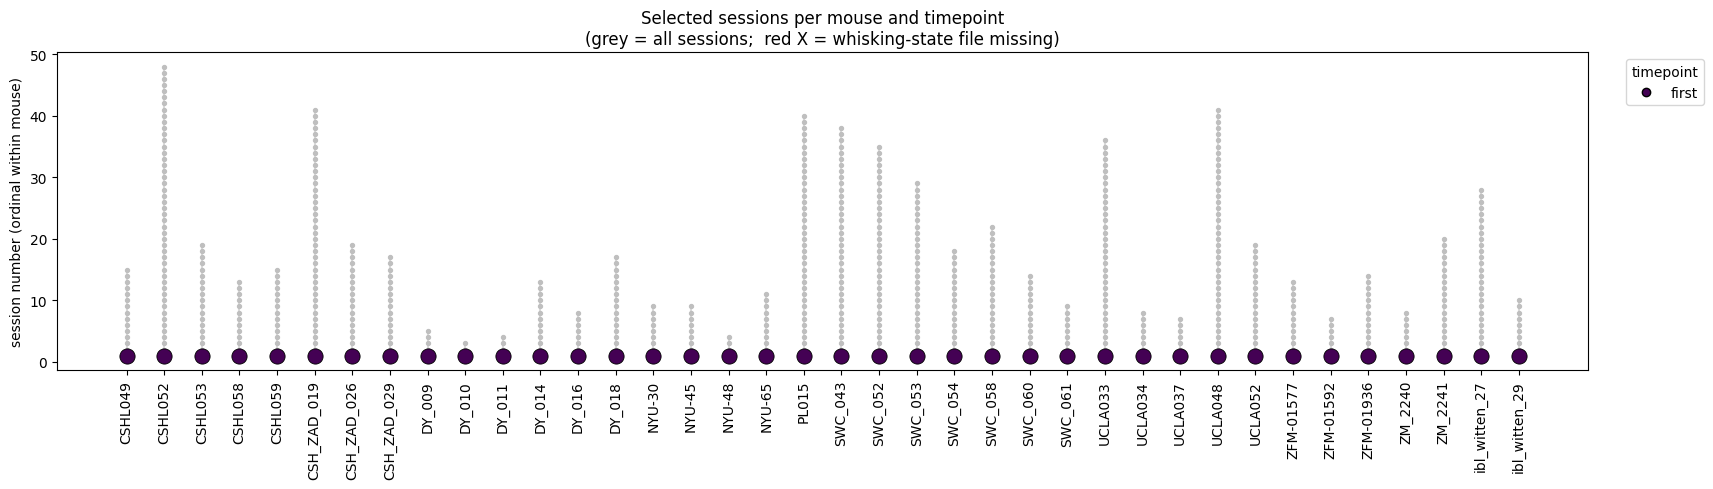

In [142]:
tp_palette = dict(zip(timepoint_names,
                      plt.cm.viridis(np.linspace(0, 1, len(timepoint_names)))))
mice = sorted(selected["mouse_name"].unique())
fig, ax = plt.subplots(figsize=(0.4 * len(mice) + 2, 5))
for x, mouse in enumerate(mice):
    sub = selected[selected["mouse_name"] == mouse]
    n = int(sub["n_sessions"].iloc[0])
    ax.plot([x] * n, range(1, n + 1), "-", color="0.85", zorder=1)
    ax.scatter([x] * n, range(1, n + 1), s=8, color="0.75", zorder=2)
    for _, r in sub.iterrows():
        ok = bool(r["has_states"])
        ax.scatter(x, r["session_number"], s=120, color=tp_palette[r["timepoint"]],
                   edgecolor=("k" if ok else "red"), linewidth=(0.6 if ok else 2.0),
                   marker=("o" if ok else "X"), zorder=3)
ax.set_xticks(range(len(mice))); ax.set_xticklabels(mice, rotation=90)
ax.set_ylabel("session number (ordinal within mouse)")
ax.set_title("Selected sessions per mouse and timepoint\n(grey = all sessions;  red X = whisking-state file missing)")
handles = [plt.Line2D([0], [0], marker="o", ls="", color=tp_palette[t],
                      markeredgecolor="k", label=t) for t in timepoint_names]
ax.legend(handles=handles, title="timepoint", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 3. Read the (already-aligned) state per bin

The `5_syllable_generation` files (`{state_file_prefix}{eid}_{mouse}`) are already aligned to
trial phases. The state for the chosen `variable` is digit `var_digit_index` of
`identifiable_states` ("{left_paw}{whisk}{lick}{wheel}"). We binarize one-vs-rest: 1 where the
bin is in `target_state`, else 0 (whisk/lick are binary -> target_state=1; left_paw/wheel have
4 states -> target_state selects which one). The mean of this 0/1 signal is the fraction of
time in that state.

In [143]:
keep_cols = ["Bin", f"{variable}_digit", "broader_label", "trial_id",
             "correct", "choice", "contrast", "block", "wsls",
             "goCueTrigger_times", "mouse_name", "session", "timepoint"]


def load_session_var(mouse_name, session, timepoint):
    """Load an already-aligned states file; keep the raw state DIGIT of `variable`
    (0..k, NaN where undefined). Per-state indicators are formed downstream."""
    f = os.path.join(states_path, f"{state_file_prefix}{session}_{mouse_name}")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing state file: {f}")
    df = pd.read_parquet(f)
    df[f"{variable}_digit"] = pd.to_numeric(
        df["identifiable_states"].astype("string").str[var_digit_index], errors="coerce")
    df["mouse_name"] = mouse_name
    df["session"] = session
    df["timepoint"] = timepoint
    return df[[c for c in keep_cols if c in df.columns]]


for timepoint in timepoint_names:
    tp_rows = selected.loc[selected["timepoint"] == timepoint]
    if len(tp_rows) == 0:
        continue
    combined = []
    for _, r in tp_rows.iterrows():
        try:
            combined.append(load_session_var(r["mouse_name"], r["session"], timepoint))
        except Exception as e:
            print(f"  skip  {r['mouse_name']}  {timepoint}  {r['session'][:8]}: "
                  f"{type(e).__name__}: {e}")
    if not combined:
        print(f"{timepoint}: no usable sessions"); continue
    tp_states = pd.concat(combined, ignore_index=True)
    out = os.path.join(results_path, f"{run_tag}_states_{timepoint}")
    tp_states.to_parquet(out, compression="gzip")
    print(f"{timepoint}: {tp_states['session'].nunique()} sessions -> {out}")

# --- which states to analyze (one plotted line each) ---
digcol = f"{variable}_digit"
_present = []
for tp in timepoint_names:
    fp = os.path.join(results_path, f"{run_tag}_states_{tp}")
    if os.path.exists(fp):
        _present += list(pd.read_parquet(fp, columns=[digcol])[digcol].dropna().unique())
_present = sorted({int(v) for v in _present})
if states_override is not None:
    STATES = list(states_override)
elif set(_present) <= {0, 1}:
    STATES = [1]                     # binary -> active state only
else:
    STATES = _present                # multi-state -> one line per state
state_palette = dict(zip(STATES, sns.color_palette("Set2", max(len(STATES), 3))))
print(f"{variable}: states present={_present} -> analyzing STATES={STATES}")

first: 38 sessions -> /home/ines/repositories/representation_learning_variability/paper-individuality/learning_individuality/wheel_states_first
wheel: states present=[0, 1, 2, 3] -> analyzing STATES=[0, 1, 2, 3]


### Sanity check: fraction whisking per trial phase

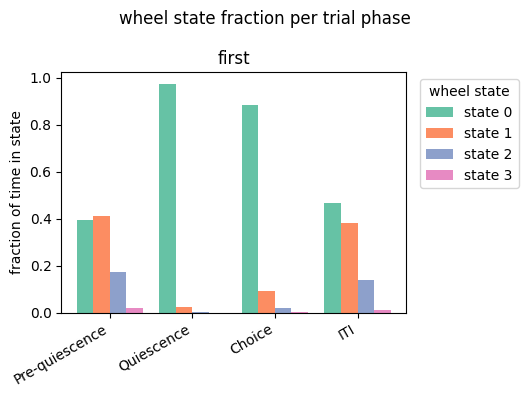

In [144]:
phase_order = ["Pre-quiescence", "Quiescence", "Choice", "ITI"]
frames = []
for tp in timepoint_names:
    f = os.path.join(results_path, f"{run_tag}_states_{tp}")
    if os.path.exists(f):
        d = pd.read_parquet(f); d["timepoint"] = tp; frames.append(d)
allst = pd.concat(frames, ignore_index=True).dropna(subset=["broader_label", digcol])
phases = [p for p in phase_order if p in allst["broader_label"].unique()]

fig, axs = plt.subplots(1, len(timepoint_names), figsize=(3.4 * len(timepoint_names) + 2, 4),
                        squeeze=False, sharey=True)
axs = axs[0]
w = 0.8 / max(len(STATES), 1)
for ax, tp in zip(axs, timepoint_names):
    sub = allst[allst["timepoint"] == tp]
    x = np.arange(len(phases))
    for si, s in enumerate(STATES):
        vals = [(sub.loc[sub["broader_label"] == p, digcol] == s).mean() for p in phases]
        ax.bar(x + si * w, vals, w, label=f"state {s}", color=state_palette[s])
    ax.set_xticks(x + w * (len(STATES) - 1) / 2); ax.set_xticklabels(phases, rotation=30, ha="right")
    ax.set_title(tp)
axs[0].set_ylabel("fraction of time in state")
axs[-1].legend(title=f"{variable} state", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"{variable} state fraction per trial phase")
plt.tight_layout(); plt.show()

## 4. Warp whisking-state sequences per trial type (mode)

In [145]:
group_vars = ["sample", "trial_type", "broader_label", "mouse_name"]
seq_col = "seq"


def bin_state_sequences(tp_states, state, trial_type_agg, target_length, estimator):
    """Binarize the digit to one state (== state), then mode-warp per trial phase."""
    d = tp_states.copy()
    d["_ind"] = np.where(d[digcol].isna(), np.nan, (d[digcol] == state).astype(float))
    d = define_trial_types(d, trial_type_agg).dropna(subset=["_ind"])
    grouped = (d.groupby(group_vars)["_ind"].apply(list).reset_index()
               .rename(columns={"_ind": "seq_raw"}))
    grouped[seq_col] = grouped["seq_raw"].apply(
        lambda s: rescale_sequence(s, target_length, estimator))
    return grouped


for timepoint in timepoint_names:
    in_file = os.path.join(results_path, f"{run_tag}_states_{timepoint}")
    if not os.path.exists(in_file):
        continue
    tp_states = pd.read_parquet(in_file)
    for s in STATES:
        seqs = bin_state_sequences(tp_states, s, trial_type_agg, target_length, estimator)
        seqs.to_parquet(os.path.join(results_path, f"{run_tag}_seq_s{s}_{timepoint}"))
    print(f"{timepoint}: warped {len(STATES)} state(s) {STATES}")

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/segmentation_functions.py:1335: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/segmentation_functions.py:1335: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'
/home/ines/repositories/representation_learning_variability/paper-individuality/segmenta

first: warped 4 state(s) [0, 1, 2, 3]


### Sanity check: whisking time-course within each phase

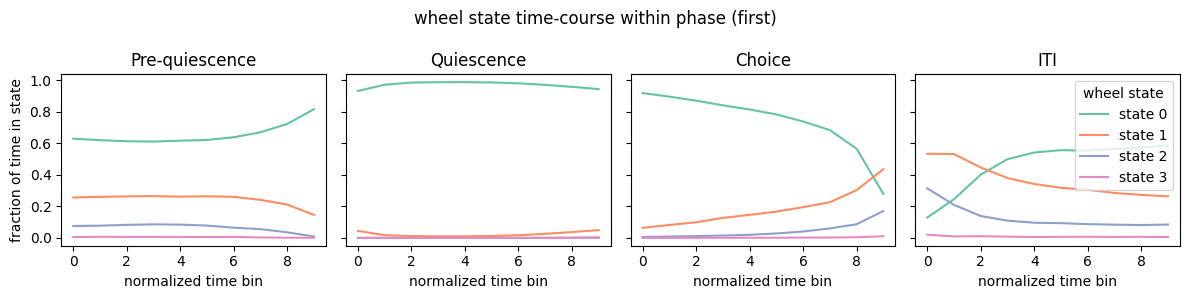

In [146]:
phase_order = ["Pre-quiescence", "Quiescence", "Choice", "ITI"]
tp = timepoint_names[0]
seqs_by_state = {}
for s in STATES:
    fp = os.path.join(results_path, f"{run_tag}_seq_s{s}_{tp}")
    if os.path.exists(fp):
        seqs_by_state[s] = pd.read_parquet(fp)
any_seq = next(iter(seqs_by_state.values()))
phases = [p for p in phase_order if p in any_seq["broader_label"].unique()]

fig, axs = plt.subplots(1, len(phases), figsize=(3 * len(phases), 3), sharey=True)
axs = np.atleast_1d(axs)
for ax, ph in zip(axs, phases):
    for s, seqs in seqs_by_state.items():
        sub = seqs[seqs["broader_label"] == ph]
        if len(sub) == 0:
            continue
        M = np.vstack([np.asarray(x, dtype=float) for x in sub[seq_col]])
        ax.plot(np.nanmean(M, axis=0), label=f"state {s}", color=state_palette[s])
    ax.set_title(ph); ax.set_xlabel("normalized time bin")
axs[0].set_ylabel("fraction of time in state")
axs[-1].legend(title=f"{variable} state")
fig.suptitle(f"{variable} state time-course within phase ({tp})")
plt.tight_layout(); plt.show()

## 5. Whisking vs LDA 1 across timepoints

In [147]:
from scipy.stats import pearsonr

epochs = ["Pre-quiescence", "Quiescence", "Choice", "ITI"]
n_perm = 5000
np.random.seed(0)
dim_col = f"lda_{lda_dim}"


def timepoint_whisk_matrix(sequences, seq_col, epochs):
    s = sequences.copy(); s["session"] = s["sample"].str[:36]
    design = (s.pivot(index=["sample", "trial_type", "mouse_name", "session"],
                      columns="broader_label", values=seq_col).reset_index())
    design = design.dropna(subset=epochs)
    mat = np.vstack(design[epochs].apply(
        lambda row: np.hstack([np.asarray(x, dtype=float) for x in row]), axis=1))
    out = pd.DataFrame(mat); out["mouse_name"] = design["mouse_name"].values
    return out


def lda_correlation_per_timestep(mat_df, mouse_lda, dim_col, n_perm=0):
    L = mat_df.shape[1] - 1
    df = mat_df.merge(mouse_lda[["mouse_name", dim_col]], on="mouse_name")
    pm = df.groupby(["mouse_name", dim_col])[list(range(L))].mean().reset_index()
    lda_vals = pm[dim_col].to_numpy(); vals = pm[list(range(L))].to_numpy()
    coeffs = np.array([pearsonr(lda_vals, vals[:, i])[0] for i in range(L)])
    if n_perm:
        perm = np.full((n_perm, L), np.nan); shuf = lda_vals.copy()
        for k in range(n_perm):
            np.random.shuffle(shuf)
            perm[k] = [pearsonr(shuf, vals[:, i])[0] for i in range(L)]
        lo, hi = np.nanpercentile(perm, [2.5, 97.5], axis=0)
        perm_median = np.nanmedian(perm, axis=0)
    else:
        lo = hi = perm_median = np.zeros(L)
    return {"coeffs": coeffs, "lo": lo, "hi": hi, "perm_median": perm_median,
            "L": L, "n_mice": len(pm)}


# per (timepoint, state)
mats, corr = {}, {}
for tp in timepoint_names:
    for s in STATES:
        fp = os.path.join(results_path, f"{run_tag}_seq_s{s}_{tp}")
        if not os.path.exists(fp):
            continue
        m = timepoint_whisk_matrix(pd.read_parquet(fp), seq_col, epochs)
        mats[(tp, s)] = m
        corr[(tp, s)] = lda_correlation_per_timestep(m, mouse_lda, dim_col, n_perm)
        print(f"{tp} | state {s}: {corr[(tp, s)]['n_mice']} mice, L={corr[(tp, s)]['L']}")

_L = next(iter(corr.values()))["L"] if corr else target_length
seq_len = _L // len(epochs)
boundaries = [seq_len * k for k in range(1, len(epochs))]
centers = [seq_len * k + seq_len / 2 for k in range(len(epochs))]

first | state 0: 38 mice, L=40
first | state 1: 38 mice, L=40
first | state 2: 38 mice, L=40
first | state 3: 38 mice, L=40


### Correlation per timestep, faceted by timepoint

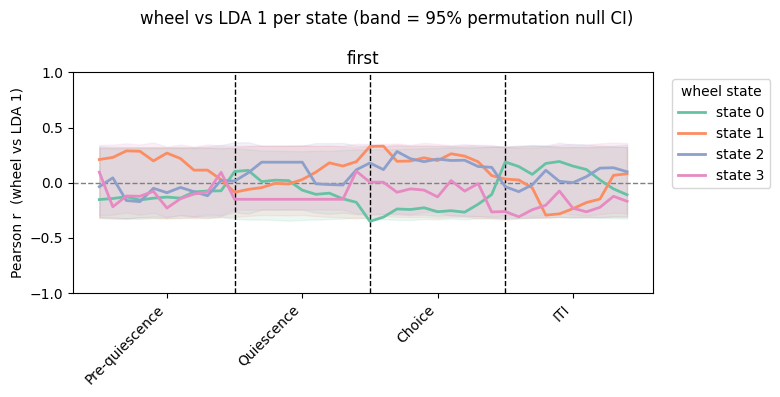

In [148]:
tps = [tp for tp in timepoint_names if any((tp, s) in corr for s in STATES)]
fig, axs = plt.subplots(1, len(tps), figsize=(8 * len(tps), 4), sharey=True, squeeze=False)
axs = axs[0]
xt = np.arange(next(iter(corr.values()))["L"])
for ax, tp in zip(axs, tps):
    ax.axhline(0, color="grey", ls="--", lw=1)
    for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
    for s in STATES:
        if (tp, s) not in corr: continue
        r = corr[(tp, s)]; c = state_palette[s]
        ax.fill_between(xt, r["lo"], r["hi"], color=c, alpha=0.12)     # 95% null CI per state
        ax.plot(xt, r["coeffs"], color=c, lw=2, label=f"state {s}")
    ax.set_ylim([-1, 1]); ax.set_title(tp)
    ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
axs[0].set_ylabel(f"Pearson r  ({variable} vs LDA {lda_dim})")
axs[-1].legend(title=f"{variable} state", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"{variable} vs LDA {lda_dim} per state (band = 95% permutation null CI)")
plt.tight_layout(); plt.show()

### Correlation curves overlaid across timepoints

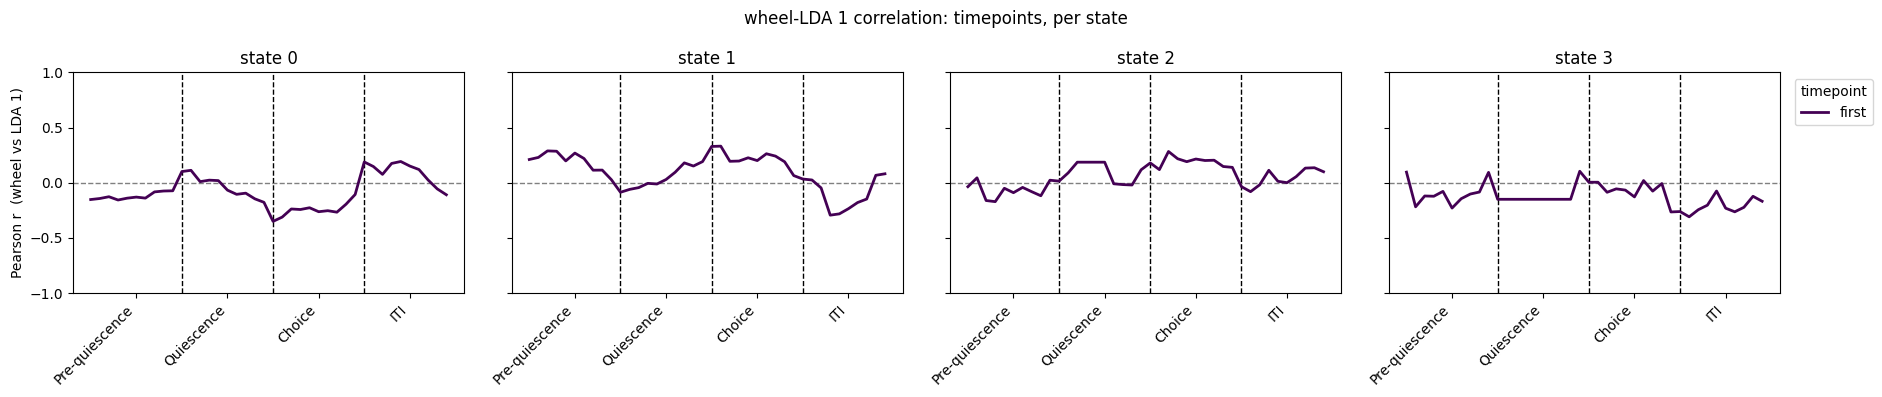

In [149]:
tp_palette2 = dict(zip(timepoint_names, plt.cm.viridis(np.linspace(0, 1, len(timepoint_names)))))
fig, axs = plt.subplots(1, len(STATES), figsize=(4.5 * len(STATES) + 1, 4), sharey=True, squeeze=False)
axs = axs[0]
xt = np.arange(next(iter(corr.values()))["L"])
for ax, s in zip(axs, STATES):
    ax.axhline(0, color="grey", ls="--", lw=1)
    for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
    for tp in timepoint_names:
        if (tp, s) in corr:
            ax.plot(xt, corr[(tp, s)]["coeffs"], color=tp_palette2[tp], lw=2, label=tp)
    ax.set_ylim([-1, 1]); ax.set_title(f"state {s}")
    ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
axs[0].set_ylabel(f"Pearson r  ({variable} vs LDA {lda_dim})")
axs[-1].legend(title="timepoint", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"{variable}-LDA {lda_dim} correlation: timepoints, per state")
plt.tight_layout(); plt.show()

### Whisking profile by LDA-1 bin (per timepoint)

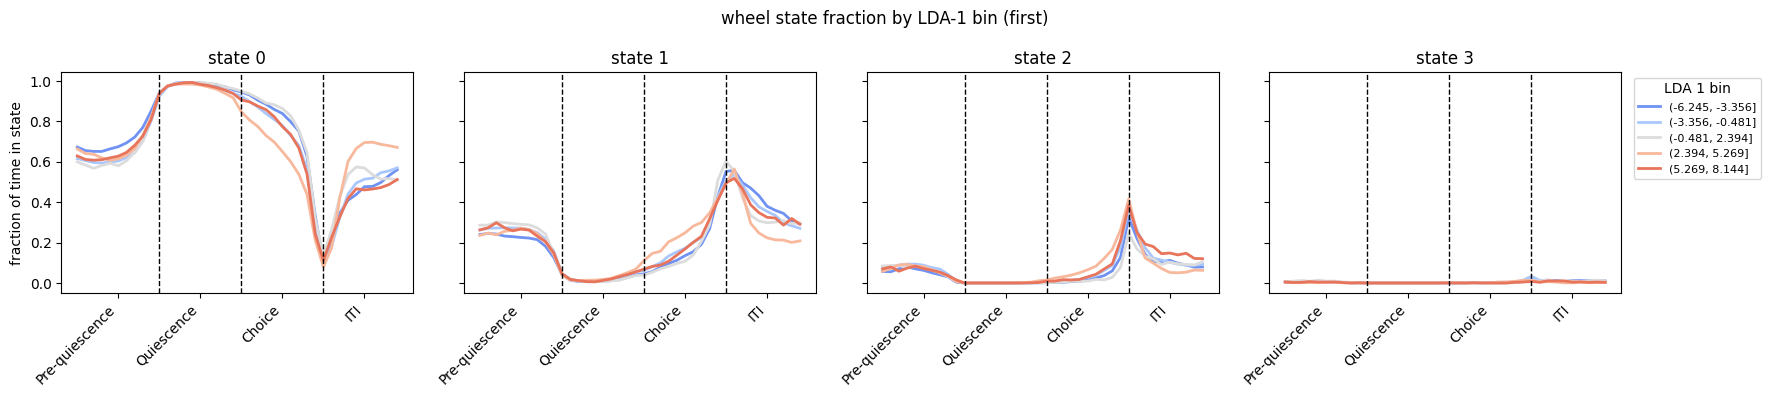

In [150]:
n_bins = 5
bin_col = f"lda_{lda_dim}_bin"
lda_binned = mouse_lda.copy()
lda_binned[bin_col] = pd.cut(lda_binned[dim_col], n_bins)
bin_levels = lda_binned[bin_col].cat.categories
bin_palette = sns.color_palette("coolwarm", n_bins)
tp = timepoint_names[0]

fig, axs = plt.subplots(1, len(STATES), figsize=(4.2 * len(STATES) + 1, 4), sharey=True, squeeze=False)
axs = axs[0]
for ax, s in zip(axs, STATES):
    if (tp, s) not in mats:
        continue
    L = corr[(tp, s)]["L"]
    df = mats[(tp, s)].merge(lda_binned[["mouse_name", bin_col]], on="mouse_name")
    for bi, level in enumerate(bin_levels):
        subm = df.loc[df[bin_col] == level, list(range(L))]
        if len(subm) == 0: continue
        ax.plot(np.arange(L), subm.to_numpy().mean(axis=0), color=bin_palette[bi], lw=2, label=str(level))
    for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
    ax.set_title(f"state {s}"); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
axs[0].set_ylabel("fraction of time in state")
axs[-1].legend(title=f"LDA {lda_dim} bin", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"{variable} state fraction by LDA-{lda_dim} bin ({tp})")
plt.tight_layout(); plt.show()

### Correlation across LDA dimensions (flattening)

Overlays the per-timestep whisking-vs-LDA correlation for each dimension in `compare_dims`,
at the first timepoint. Less-important (higher-index) dimensions should flatten toward zero.

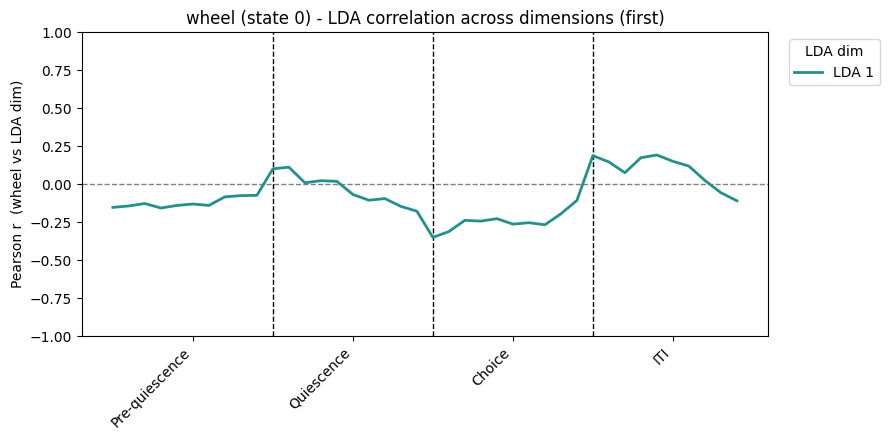

In [151]:
tp = timepoint_names[0]
s0 = STATES[0]                    # flattening shown for one state
mat = mats[(tp, s0)]
dim_palette = sns.color_palette("viridis", len(compare_dims))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color="grey", ls="--", lw=1)
for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
for c, d in zip(dim_palette, compare_dims):
    r = lda_correlation_per_timestep(mat, mouse_lda, f"lda_{d}", n_perm=0)
    ax.plot(np.arange(r["L"]), r["coeffs"], color=c, lw=2, label=f"LDA {d}")
ax.set_ylim([-1, 1]); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
ax.set_ylabel(f"Pearson r  ({variable} vs LDA dim)")
ax.set_title(f"{variable} (state {s0}) - LDA correlation across dimensions ({tp})")
ax.legend(title="LDA dim", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 6. Trait persistence: is the session-1 profile a (scaled) version of proficiency?

Per **state**: projection test (significance) + regression slope (effect size), vs a
shuffle-LDA-across-mice null. `r_prof` for each state is read from the saved LDA profile
(`whisk`/`lick` columns, or `{variable}_{state}` for multi-state — states without a matching
profile column are skipped here but still appear in the session-1 plots above).

In [152]:
# ---- proficiency profiles per state (trait templates) ----
proficiency_profile_file = clustering_path + f"lda_corr_profile_component{lda_dim - 1}_<DATE>"
prof = pd.read_parquet(proficiency_profile_file)


def prof_col(variable, state):
    """Profile column for this (variable, state). whisk/lick are single (binary);
    multi-state variables expect a per-state column named f'{variable}_{state}'."""
    return variable if variable in ("whisk", "lick") else f"{variable}_{state}"


Lbins = next(iter(corr.values()))["L"]
r_prof_by_state = {}
for s in STATES:
    col = prof_col(variable, s)
    if col in prof.columns and len(prof[col]) == Lbins:
        r_prof_by_state[s] = prof[col].to_numpy()
    else:
        why = "missing column" if col not in prof.columns else f"len {len(prof.get(col, []))}!={Lbins}"
        print(f"  no proficiency profile for {variable} state {s} (col '{col}': {why}) -> skipped")
print(f"proficiency profiles available for states: {sorted(r_prof_by_state)}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/ines/repositories/representation_learning_variability/paper-individuality/clustering/lda_corr_profile_component0_<DATE>'

In [ ]:
def _per_mouse(mat_df, mouse_lda, dim_col):
    L = mat_df.shape[1] - 1
    df = mat_df.merge(mouse_lda[["mouse_name", dim_col]], on="mouse_name")
    pm = df.groupby(["mouse_name", dim_col])[list(range(L))].mean().reset_index()
    return pm[dim_col].to_numpy(float), pm[list(range(L))].to_numpy(float)


def trait_persistence(early_mat, r_prof, mouse_lda, dim_col, bins=None, n_perm=5000, seed=0):
    """Projection test + regression slope vs a shuffle-LDA-across-mice null.
    bins=None -> whole trial; pass an index array to restrict to one epoch."""
    rng = np.random.default_rng(seed)
    lda_vals, Y = _per_mouse(early_mat, mouse_lda, dim_col)
    Z = (Y - Y.mean(0)) / (Y.std(0) + 1e-12)
    bins = np.arange(Y.shape[1]) if bins is None else np.asarray(bins)
    rp = np.asarray(r_prof, float)[bins]
    w = rp / (np.linalg.norm(rp) + 1e-12)
    score = Z[:, bins] @ w
    r_proj = pearsonr(score, lda_vals)[0]
    r_early = np.array([pearsonr(lda_vals, Y[:, b])[0] for b in bins])
    fin = np.isfinite(rp) & np.isfinite(r_early)
    slope, intercept = np.polyfit(rp[fin], r_early[fin], 1) if fin.sum() >= 2 else (np.nan, np.nan)
    r_shape = pearsonr(rp[fin], r_early[fin])[0] if fin.sum() >= 2 else np.nan
    npj = np.empty(n_perm); nsl = np.empty(n_perm)
    for k in range(n_perm):
        p = rng.permutation(lda_vals)
        npj[k] = pearsonr(score, p)[0]
        re = np.array([pearsonr(p, Y[:, b])[0] for b in bins])
        nsl[k] = np.polyfit(rp[fin], re[fin], 1)[0] if fin.sum() >= 2 else np.nan
    return dict(r_proj=r_proj, p_proj=(1 + np.sum(npj >= r_proj)) / (n_perm + 1),
                slope=slope, intercept=intercept,
                p_slope=(1 + np.nansum(nsl >= slope)) / (n_perm + 1),
                r_shape=r_shape, r_early=r_early, score=score, lda=lda_vals, n=len(lda_vals))


tp = timepoint_names[0]
res_by_state = {}
for s in STATES:
    if s in r_prof_by_state and (tp, s) in mats:
        res_by_state[s] = trait_persistence(mats[(tp, s)], r_prof_by_state[s], mouse_lda, dim_col, n_perm=n_perm)
summary = pd.DataFrame([{"state": s, "n": r["n"], "r_proj": r["r_proj"], "p_proj": r["p_proj"],
                         "slope": r["slope"], "p_slope": r["p_slope"], "profile_r": r["r_shape"]}
                        for s, r in res_by_state.items()])
print(f"Trait persistence per state ({variable}, LDA {lda_dim}, {tp}):")
print(summary.to_string(index=False) if len(summary) else "  (no states with a proficiency profile)")

[lick, state 1, LDA 2, n=38 mice]
  Projection : r(score, LDA2) = -0.174   p = 0.8476
  Slope      : r_early ~ r_prof  beta = +0.148   p = 0.0816
  Profile r  : corr(r_early, r_prof) = +0.874


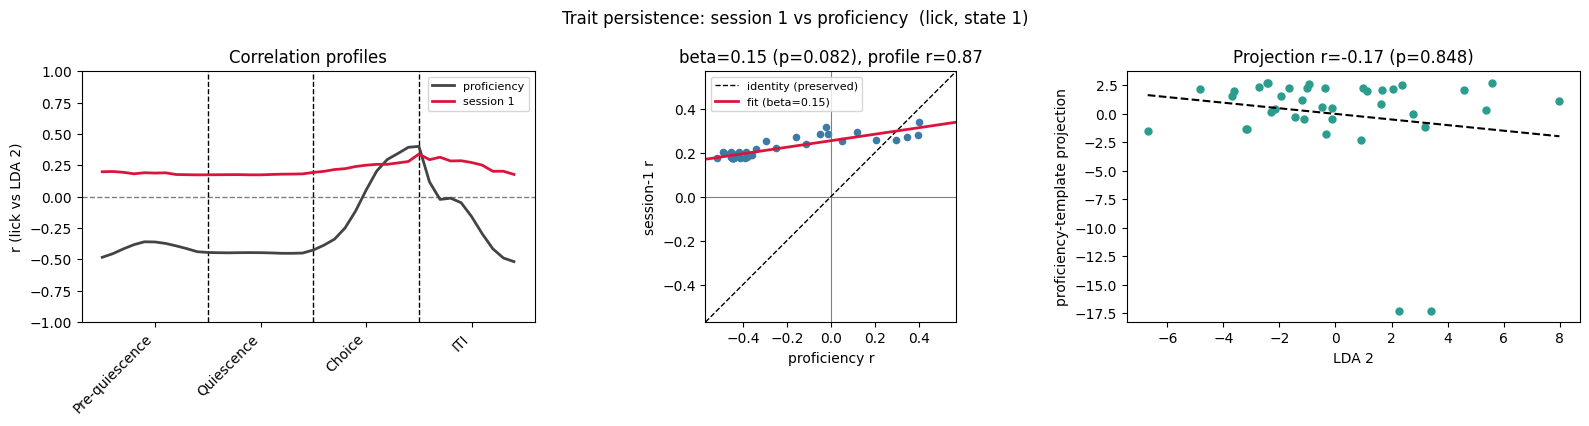

In [ ]:
sts = list(res_by_state)
if sts:
    fig, axs = plt.subplots(1, len(sts), figsize=(4.6 * len(sts) + 1, 4), sharey=True, squeeze=False)
    axs = axs[0]
    for ax, s in zip(axs, sts):
        r = res_by_state[s]; rp = r_prof_by_state[s]
        ax.axhline(0, color="grey", ls="--", lw=1)
        for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
        ax.plot(np.arange(len(rp)), rp, color="#444444", lw=2, label="proficiency")
        ax.plot(np.arange(len(r["r_early"])), r["r_early"], color=state_palette[s], lw=2, label="session 1")
        ax.set_ylim([-1, 1]); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
        ax.set_title(f"state {s}: proj r={r['r_proj']:.2f} (p={r['p_proj']:.3f}), beta={r['slope']:.2f}")
    axs[0].set_ylabel(f"r ({variable} vs LDA {lda_dim})"); axs[0].legend(fontsize=8)
    fig.suptitle(f"Trait persistence: session 1 vs proficiency ({variable})")
    plt.tight_layout(); plt.show()
else:
    print("No states with a proficiency profile - nothing to plot.")

### 6b. Trait persistence per trial epoch x state

Whole-profile projection restricted to each epoch's bins, per state. p-values are
**FDR-BH corrected across the whole state x epoch grid**.

Per-epoch trait persistence (lick, LDA 2, n=38 mice):
         epoch    r_proj   p_proj     slope  p_slope
Pre-quiescence -0.188903 0.868226 -0.065500 0.641472
    Quiescence -0.176983 0.849430 -1.000409 0.853229
        Choice  0.050984 0.368726  0.089020 0.161968
           ITI -0.161415 0.830834  0.173548 0.080584


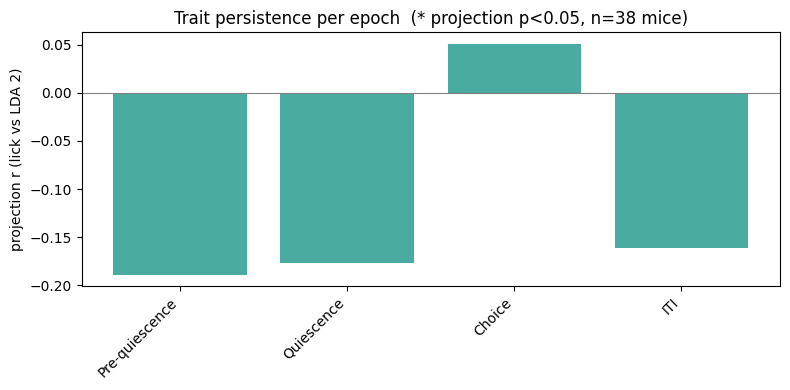

In [ ]:
from statsmodels.stats.multitest import multipletests

tp = timepoint_names[0]
seq_len = next(iter(corr.values()))["L"] // len(epochs)
rows = []
for s in res_by_state:
    for e, ep in enumerate(epochs):
        bidx = np.arange(e * seq_len, (e + 1) * seq_len)
        r = trait_persistence(mats[(tp, s)], r_prof_by_state[s], mouse_lda, dim_col, bins=bidx, n_perm=n_perm)
        rows.append({"state": s, "epoch": ep, "r_proj": r["r_proj"], "p_proj": r["p_proj"], "slope": r["slope"]})
by = pd.DataFrame(rows)
if len(by):
    by["p_proj_fdr"] = multipletests(by["p_proj"], method="fdr_bh")[1]   # across all state x epoch
    print(by.to_string(index=False))
    fig, ax = plt.subplots(figsize=(1.7 * len(epochs) + 2, 4))
    x = np.arange(len(epochs)); w = 0.8 / max(len(res_by_state), 1)
    for si, s in enumerate(res_by_state):
        sub = by[by["state"] == s].set_index("epoch").reindex(epochs)
        ax.bar(x + si * w, sub["r_proj"], w, color=state_palette[s], label=f"state {s}")
        for xi, (_, row) in enumerate(sub.iterrows()):
            if pd.notna(row["p_proj_fdr"]) and row["p_proj_fdr"] < 0.05:
                ax.text(x[xi] + si * w, row["r_proj"], "*", ha="center",
                        va="bottom" if row["r_proj"] >= 0 else "top", color="crimson", fontsize=13)
    ax.axhline(0, color="grey", lw=.8)
    ax.set_xticks(x + w * (len(res_by_state) - 1) / 2); ax.set_xticklabels(epochs, rotation=45, ha="right")
    ax.set_ylabel(f"projection r ({variable} vs LDA {lda_dim})")
    ax.set_title("Trait persistence per epoch x state  (* FDR p<0.05)")
    ax.legend(title=f"{variable} state", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("No states with a proficiency profile.")

## 7. Per-bin early-vs-proficient alignment, per state (FDR across bins)

Per state and per trial bin: alignment `d_b = r_prof(b) * r_early(b)`, shuffle-LDA null,
one-sided p, **FDR-BH across bins within each state** (states are an additional axis).

per-bin early-vs-proficient (lick, LDA 2, n=38 mice): 0/40 bins significant after FDR (p<0.05)


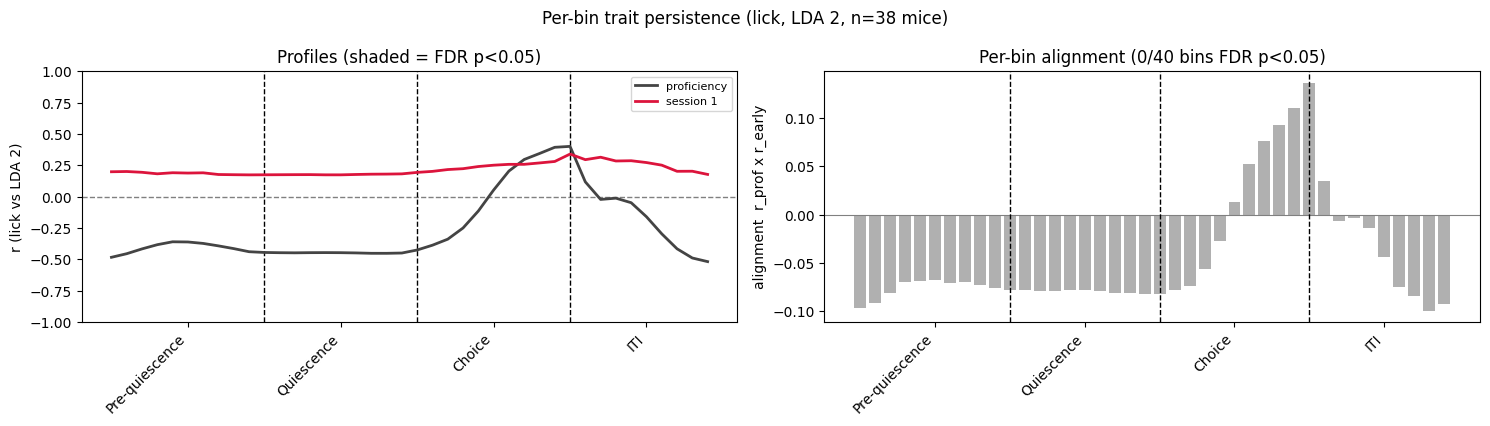

In [ ]:
from statsmodels.stats.multitest import multipletests


def per_bin_persistence(early_mat, r_prof, mouse_lda, dim_col, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    lda_vals, Y = _per_mouse(early_mat, mouse_lda, dim_col)
    L = Y.shape[1]; rp = np.asarray(r_prof, float)
    r_early = np.array([pearsonr(lda_vals, Y[:, b])[0] for b in range(L)])
    d = rp * r_early
    null = np.empty((n_perm, L))
    for k in range(n_perm):
        p = rng.permutation(lda_vals)
        null[k] = rp * np.array([pearsonr(p, Y[:, b])[0] for b in range(L)])
    ge = np.sum(null >= d[None, :], axis=0)
    p_bin = np.full(L, np.nan); fin = np.isfinite(d)
    p_bin[fin] = (1 + ge[fin]) / (n_perm + 1)
    p_fdr = np.full(L, np.nan); p_fdr[fin] = multipletests(p_bin[fin], method="fdr_bh")[1]
    return dict(r_early=r_early, d=d, p_bin=p_bin, p_fdr=p_fdr, L=L, n=len(lda_vals))


tp = timepoint_names[0]
sts = list(res_by_state)
if sts:
    fig, axs = plt.subplots(1, len(sts), figsize=(5 * len(sts) + 1, 4), sharey=True, squeeze=False)
    axs = axs[0]
    for ax, s in zip(axs, sts):
        pb = per_bin_persistence(mats[(tp, s)], r_prof_by_state[s], mouse_lda, dim_col, n_perm=n_perm)
        sig = pb["p_fdr"] < 0.05; xb = np.arange(pb["L"])
        ax.axhline(0, color="grey", ls="--", lw=1)
        for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
        for b in np.where(sig)[0]: ax.axvspan(b - 0.5, b + 0.5, color="crimson", alpha=0.12)
        ax.plot(xb, r_prof_by_state[s], color="#444444", lw=2, label="proficiency")
        ax.plot(xb, pb["r_early"], color=state_palette[s], lw=2, label="session 1")
        ax.set_ylim([-1, 1]); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
        ax.set_title(f"state {s}: {int(np.nansum(sig))}/{pb['L']} bins FDR<0.05")
    axs[0].set_ylabel(f"r ({variable} vs LDA {lda_dim})"); axs[0].legend(fontsize=8)
    fig.suptitle(f"Per-bin early-vs-proficient ({variable}); FDR across bins within each state")
    plt.tight_layout(); plt.show()
else:
    print("No states with a proficiency profile - nothing to plot.")